In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, confusion_matrix
import warnings
import pickle

In [ ]:
df = pd.read_csv('/content/PS_20174392719_1491204439457_log.csv')
display(df.head())

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1387874 entries, 0 to 1387873
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1387874 non-null  int64  
 1   type            1387874 non-null  object 
 2   amount          1387874 non-null  float64
 3   nameOrig        1387874 non-null  object 
 4   oldbalanceOrg   1387874 non-null  float64
 5   newbalanceOrig  1387874 non-null  float64
 6   nameDest        1387874 non-null  object 
 7   oldbalanceDest  1387874 non-null  float64
 8   newbalanceDest  1387874 non-null  float64
 9   isFraud         1387873 non-null  float64
 10  isFlaggedFraud  1387873 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 116.5+ MB
None


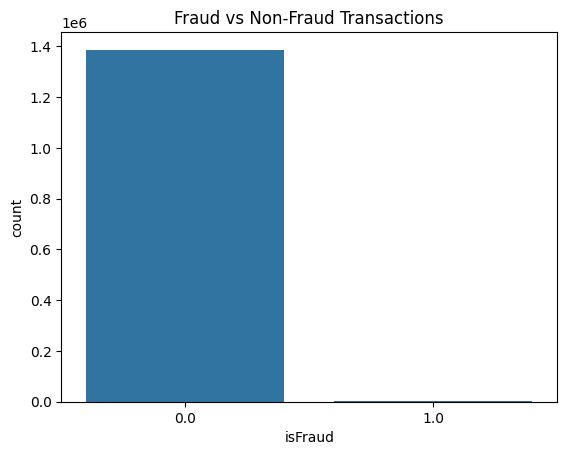

In [ ]:
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [ ]:
display(df.describe())

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.387874e+06,1.387874e+06,1.387874e+06,1.387874e+06,1.387874e+06,1.387874e+06,1.387873e+06,1387873.0
mean,5.261857e+01,1.627251e+05,8.737655e+05,8.945704e+05,9.901607e+05,1.119479e+06,1.132668e-03,0.0
std,4.724415e+01,2.703034e+05,2.965599e+06,3.001967e+06,2.305943e+06,2.413709e+06,3.363609e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.600000e+01,1.315986e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,3.600000e+01,7.935446e+04,1.540306e+04,0.000000e+00,1.335925e+05,2.273013e+05,0.000000e+00,0.0
75%,9.400000e+01,2.189144e+05,1.289467e+05,1.709548e+05,9.364506e+05,1.159371e+06,0.000000e+00,0.0
max,1.390000e+02,1.000000e+07,3.893942e+07,3.894623e+07,4.220740e+07,4.220740e+07,1.000000e+00,0.0


In [ ]:
print(df["isFraud"].value_counts())

isFraud
0.0    1386301
1.0       1572
Name: count, dtype: int64


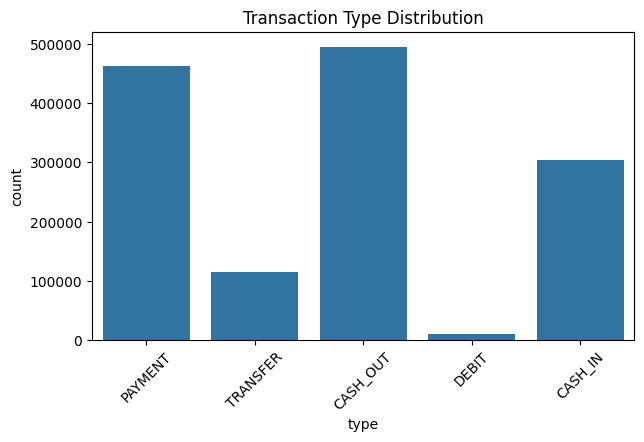

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x="type", data=df)
plt.title("Transaction Type Distribution")
plt.xticks(rotation=45)
plt.show()

In [ ]:
print(df["type"].value_counts())

type
CASH_OUT    496025
PAYMENT     463260
CASH_IN     304315
TRANSFER    115115
DEBIT         9159
Name: count, dtype: int64


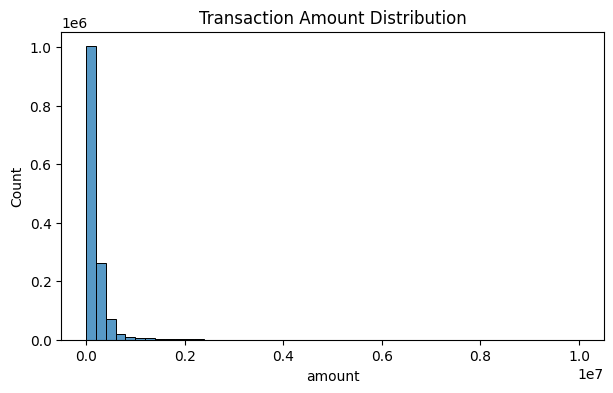

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df["amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

In [ ]:
print(df["amount"].describe())

count    1.387874e+06
mean     1.627251e+05
std      2.703034e+05
min      1.000000e-01
25%      1.315986e+04
50%      7.935446e+04
75%      2.189144e+05
max      1.000000e+07
Name: amount, dtype: float64


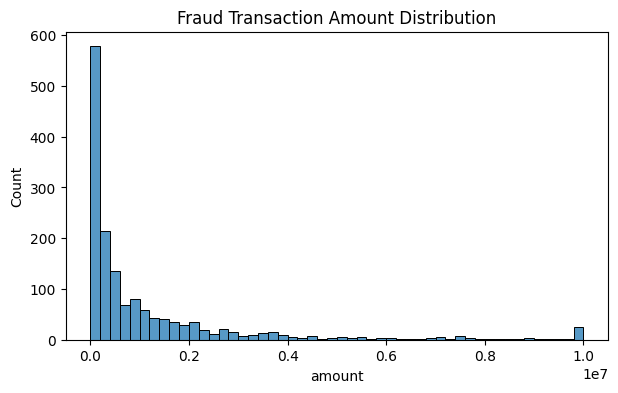

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(df[df["isFraud"]==1]["amount"], bins=50)
plt.title("Fraud Transaction Amount Distribution")
plt.show()

In [ ]:
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           1
isFlaggedFraud    1
dtype: int64


In [ ]:
df.dropna(inplace=True)
print(df.isnull().sum())
display(df.info())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 1387873 entries, 0 to 1387872
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1387873 non-null  int64  
 1   type            1387873 non-null  object 
 2   amount          1387873 non-null  float64
 3   nameOrig        1387873 non-null  object 
 4   oldbalanceOrg   1387873 non-null  float64
 5   newbalanceOrig  1387873 non-null  float64
 6   nameDest        1387873 non-null  object 
 7   oldbalanceDest  1387873 non-null  float64
 8   newbalanceDest  1387873 non-null  float64
 9   isFraud         1387873 non-null  float64
 10  isFlaggedFraud  1387873 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory u

None

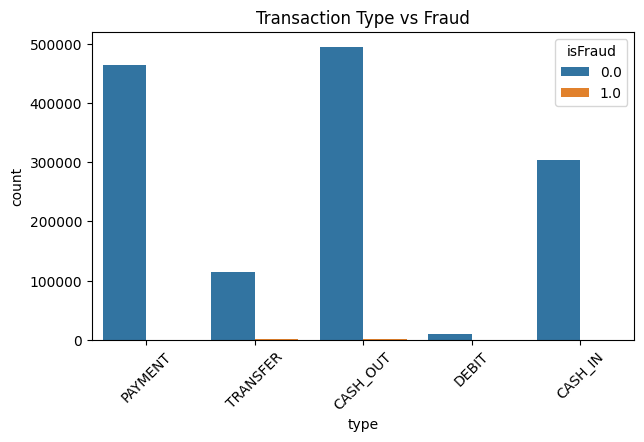

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x="type", hue="isFraud", data=df)
plt.title("Transaction Type vs Fraud")
plt.xticks(rotation=45)
plt.show()

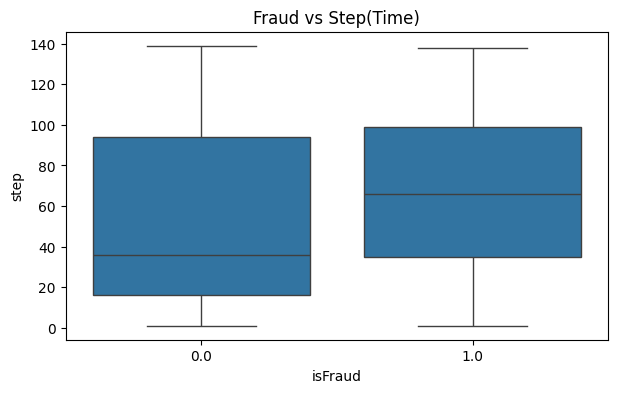

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x="isFraud", y="step", data=df)
plt.title("Fraud vs Step(Time)")
plt.show()

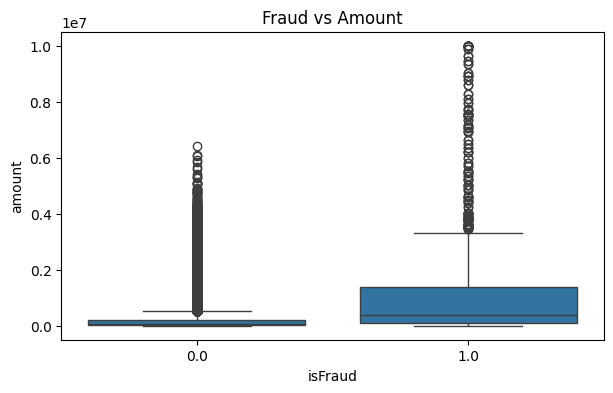

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x="isFraud", y="amount", data=df)
plt.title("Fraud vs Amount")
plt.show()

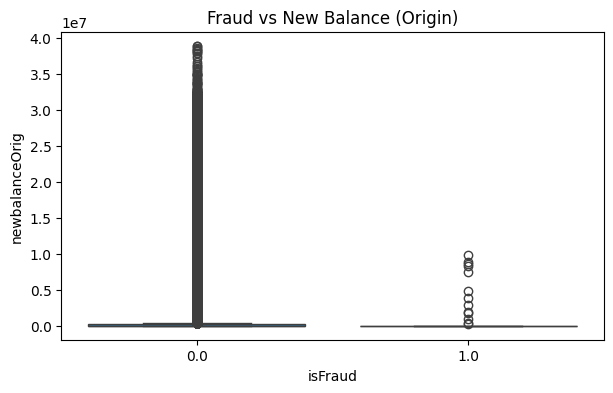

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x="isFraud", y="newbalanceOrig", data=df)
plt.title("Fraud vs New Balance (Origin)")
plt.show()

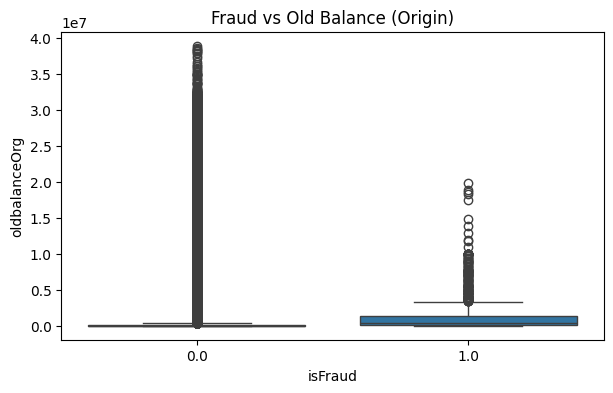

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x="isFraud", y="oldbalanceOrg", data=df)
plt.title("Fraud vs Old Balance (Origin)")
plt.show()

In [ ]:
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


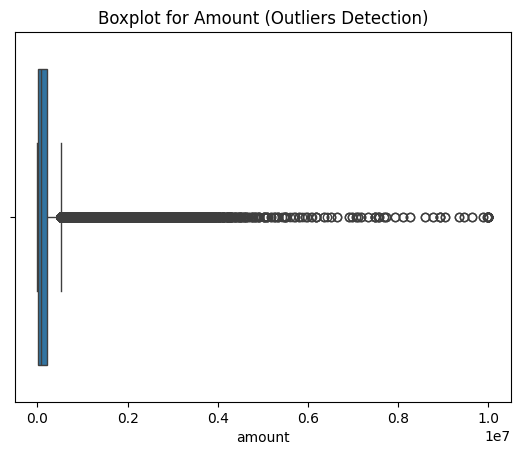

In [ ]:
sns.boxplot(x=df["amount"])
plt.title("Boxplot for Amount (Outliers Detection)")
plt.show()

In [ ]:
from scipy import stats
import numpy as np

print(stats.mode(df["amount"]))

ModeResult(mode=np.float64(10000000.0), count=np.int64(22))


In [ ]:
import numpy as np

print(np.mean(df["amount"]))

162724.9275096425


In [ ]:
import numpy as np

q1 = np.quantile(df["amount"], 0.25)
q3 = np.quantile(df["amount"], 0.75)

IQR = q3 - q1

print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"IQR: {IQR}")

Q1: 13159.81
Q3: 218913.98
IQR: 205754.17


In [ ]:
def transformationPlot(feature):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.distplot(feature)

    plt.subplot(1,2,2)
    stats.probplot(feature, dist="norm", plot=plt)

    plt.show()

/tmp/ipython-input-639153979.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(feature)


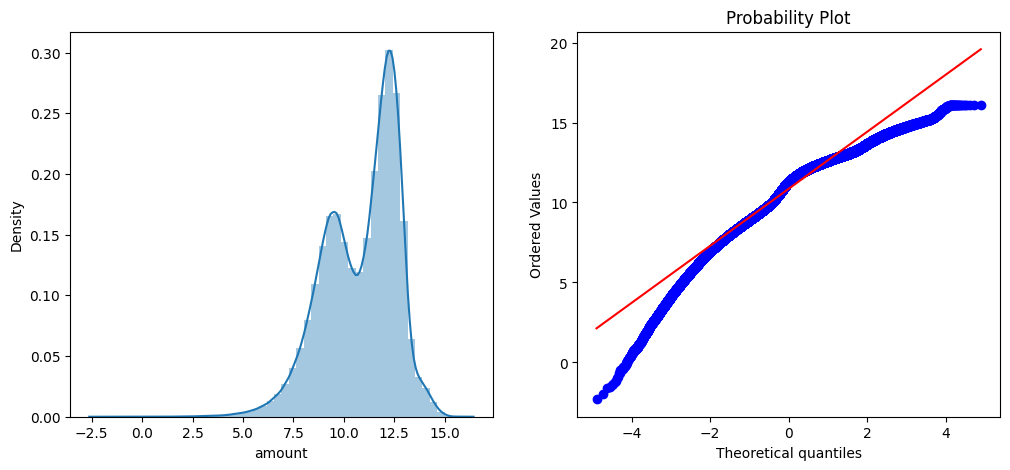

In [ ]:
import numpy as np

transformationPlot(np.log(df["amount"]))

df["amount"] = np.log(df["amount"])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["type"] = le.fit_transform(df["type"])

display(df.head())

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9.194174,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,3,7.530630,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,4,5.198497,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,1,5.198497,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,3,9.364617,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
print(df["isFraud"].isna().sum())

0


In [ ]:
df = df.dropna(subset=["isFraud"])

In [ ]:
df["isFraud"] = df["isFraud"].astype(int)

In [ ]:
df = df.drop(["nameOrig", "nameDest"], axis=1, errors='ignore')

In [ ]:
from sklearn.model_selection import train_test_split

# X = Features (all columns except target)
X = df.drop("isFraud", axis=1)

# y = Target column
y = df["isFraud"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1110298, 8)
X_test shape : (277575, 8)
y_train shape: (1110298,)
y_test shape : (277575,)


Random Forest Accuracy: 0.9997622264252904

Confusion Matrix:
 [[277260      1]
 [    65    249]]


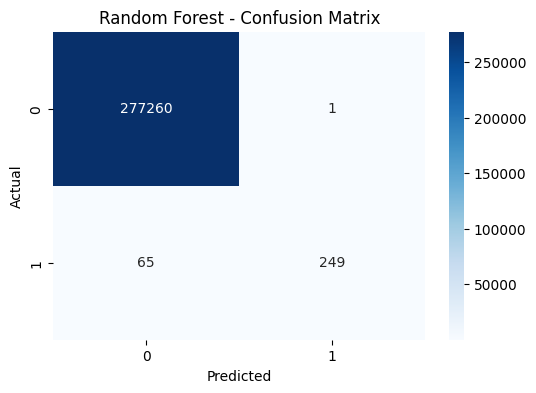


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    277261
           1       1.00      0.79      0.88       314

    accuracy                           1.00    277575
   macro avg       1.00      0.90      0.94    277575
weighted avg       1.00      1.00      1.00    277575



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# 2) Train the model
rf_model.fit(X_train, y_train)

# 3) Predict on test data
y_pred_rf = rf_model.predict(X_test)

# 4) Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

# 5) Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:\n", cm_rf)

# 6) Confusion Matrix Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 7) Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Decision Tree Accuracy: 0.9996037107088175

Confusion Matrix:
 [[277218     43]
 [    67    247]]


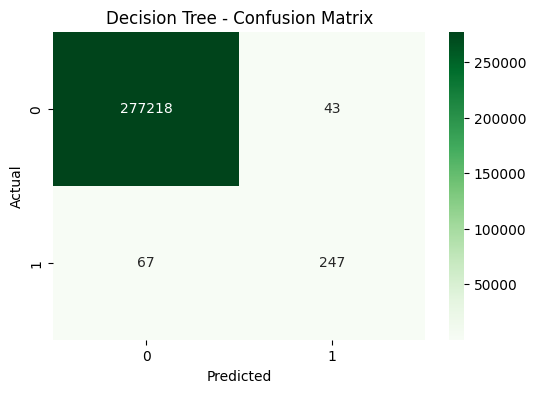


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    277261
           1       0.85      0.79      0.82       314

    accuracy                           1.00    277575
   macro avg       0.93      0.89      0.91    277575
weighted avg       1.00      1.00      1.00    277575



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Create Decision Tree model
dt_model = DecisionTreeClassifier(
    criterion='gini',   # or 'entropy'
    max_depth=None,     # you can limit depth like max_depth=5 to avoid overfitting
    random_state=42
)

# 2) Train the model
dt_model.fit(X_train, y_train)

# 3) Predict on test data
y_pred_dt = dt_model.predict(X_test)

# 4) Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

# 5) Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix:\n", cm_dt)

# 6) Confusion Matrix Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 7) Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Extra Trees Accuracy: 0.9997153922363325

Confusion Matrix:
 [[277259      2]
 [    77    237]]


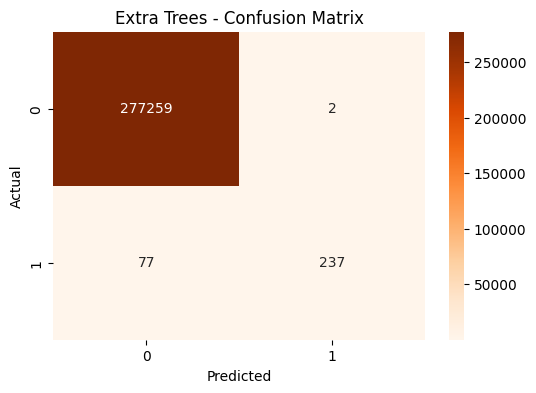


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    277261
           1       0.99      0.75      0.86       314

    accuracy                           1.00    277575
   macro avg       1.00      0.88      0.93    277575
weighted avg       1.00      1.00      1.00    277575



In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Create Extra Trees model
et_model = ExtraTreesClassifier(
    n_estimators=100,     # number of trees
    random_state=42,
    max_features='sqrt',  # square root of features for split
    n_jobs=-1             # use all cores
)

# 2) Train the model
et_model.fit(X_train, y_train)

# 3) Predict on test data
y_pred_et = et_model.predict(X_test)

# 4) Accuracy
et_accuracy = accuracy_score(y_test, y_pred_et)
print("Extra Trees Accuracy:", et_accuracy)

# 5) Confusion Matrix
cm_et = confusion_matrix(y_test, y_pred_et)
print("\nConfusion Matrix:\n", cm_et)

# 6) Confusion Matrix Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm_et, annot=True, fmt="d", cmap="Oranges")
plt.title("Extra Trees - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 7) Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_et))

SVM Accuracy: 0.9992614608664325

Confusion Matrix:
 [[277261      0]
 [   205    109]]


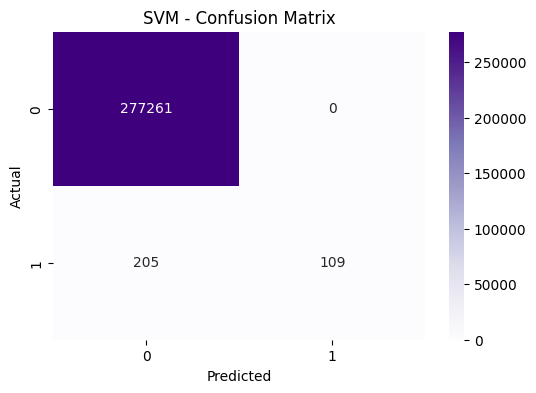


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    277261
           1       1.00      0.35      0.52       314

    accuracy                           1.00    277575
   macro avg       1.00      0.67      0.76    277575
weighted avg       1.00      1.00      1.00    277575



In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import pandas as pd

# X = Features (all columns except target)
X = df.drop("isFraud", axis=1)

# y = Target column
y = df["isFraud"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 1) Feature scaling (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2) Create SVM model
svm_model = SVC(
    kernel='rbf',      # radial basis function kernel
    C=1.0,             # regularization parameter
    gamma='scale',     # kernel coefficient
    random_state=42
)

# 3) Train the model
svm_model.fit(X_train_scaled, y_train)

# 4) Predict on test data
y_pred_svm = svm_model.predict(X_test_scaled)

# 5) Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)

# 6) Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix:\n", cm_svm)

# 7) Confusion Matrix Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Purples")
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 8) Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:40:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9998162658740881

Confusion Matrix:
 [[277257      4]
 [    47    267]]


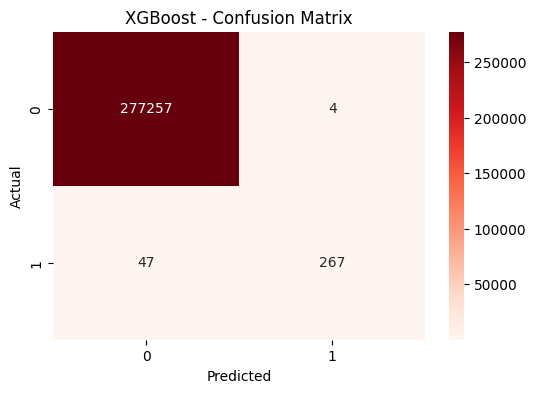


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    277261
           1       0.99      0.85      0.91       314

    accuracy                           1.00    277575
   macro avg       0.99      0.93      0.96    277575
weighted avg       1.00      1.00      1.00    277575



In [ ]:
# Install XGBoost if not installed
# !pip install xgboost

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,      # number of trees
    learning_rate=0.1,     # step size shrinkage
    max_depth=5,           # max depth of tree
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'  # avoid warning
)

# 2) Train the model
xgb_model.fit(X_train, y_train)

# 3) Predict on test data
y_pred_xgb = xgb_model.predict(X_test)

# 4) Accuracy
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", xgb_accuracy)

# 5) Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:\n", cm_xgb)

# 6) Confusion Matrix Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Reds")
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 7) Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))


Model Comparison (Tree-based + SVM/XGBoost):

           Model  Accuracy  Precision    Recall  F1-Score
0  Decision Tree  0.999604   0.851724  0.786624  0.817881
1  Random Forest  0.999762   0.996000  0.792994  0.882979
2    Extra Trees  0.999715   0.991632  0.754777  0.857143
3            SVM  0.999261   1.000000  0.347134  0.515366
4        XGBoost  0.999816   0.985240  0.850318  0.912821


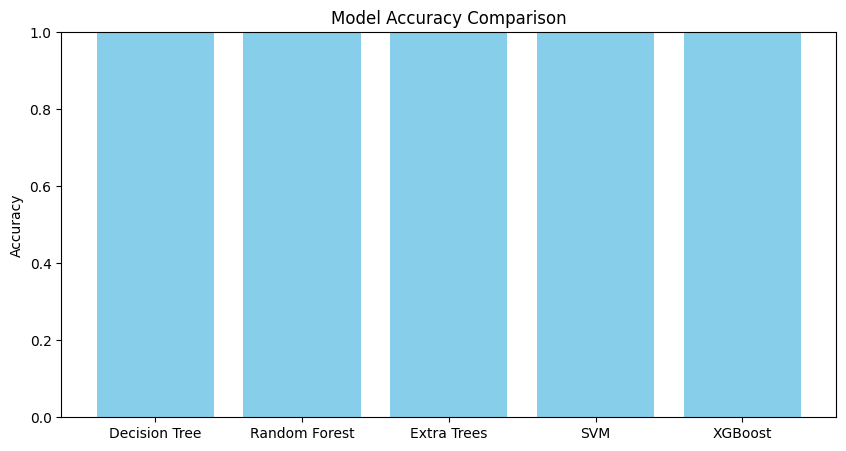

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# Models and predictions
models = ["Decision Tree", "Random Forest", "Extra Trees", "SVM", "XGBoost"]
predictions = [y_pred_dt, y_pred_rf, y_pred_et, y_pred_svm, y_pred_xgb]

# Metrics
accuracy = []
precision = []
recall = []
f1 = []

for y_pred in predictions:
    accuracy.append(accuracy_score(y_test, y_pred))
    precision.append(precision_score(y_test, y_pred))
    recall.append(recall_score(y_test, y_pred))
    f1.append(f1_score(y_test, y_pred))

# Create DataFrame
comparison_df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
})

print("\nModel Comparison (Tree-based + SVM/XGBoost):\n")
print(comparison_df)

# Plot Accuracy
plt.figure(figsize=(10,5))
plt.bar(models, accuracy, color='skyblue')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

In [ ]:
import pickle

# Example: Saving Random Forest model
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [ ]:
# Load the model
with open("random_forest_model.pkl", "rb") as f:
    loaded_rf_model = pickle.load(f)

# Predict using the loaded model
y_pred_loaded = loaded_rf_model.predict(X_test)
print("Predictions using loaded model:", y_pred_loaded[:10])

Predictions using loaded model: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Load scaler
with open("scaler.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)

X_test_scaled = loaded_scaler.transform(X_test)

In [ ]:
upper_bound = q3 + (1.5 * IQR)
lower_bound = q1 - (1.5 * IQR)

print("q1 :", q1)
print("q3 :", q3)
print("IQR :", IQR)
print("Upper Bound :", upper_bound)
print("Lower Bound :", lower_bound)

print("Skewed data :", len(df[df["amount"] > upper_bound]))
print("Skewed data :", len(df[df["amount"] < lower_bound]))

q1 : 13159.81
q3 : 218913.98
IQR : 205754.17
Upper Bound : 527545.235
Lower Bound : -295471.445
Skewed data : 0
Skewed data : 0
